# SBI posterior parameter evaluation — cnn4e32-lipschitz-ae-reduced

Evaluates `exp_cnn4e32-lipschitz-ae-reduced_maf5_freeze-maf_1M`: AE v2 with hourglass CNN encoder
(24 cont channels, 32-dim latent), 6-layer 512-wide MLP decoder with smoothness penalty (λ=0.1),
Lipschitz constraint on both phases (C=2.0). MAF-5 with patience=50, freeze-warm 10 epochs.
24-param theta (HR excluded).

**Point estimate comparison**: posterior mean vs GT — MAE, Median AE, MAPE  
**Posterior-specific**: 90% credible interval coverage per parameter  
**AE diagnostics**: phase 1+2 val MSE vs previous Lipschitz run  
**Lipschitz-specific**: spectral norm per layer, Lipschitz ratio test

In [14]:
import json
import re
import glob
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

ROOT = Path(globals()['_dh'][0])  # kernel cwd = ~/cv-sbi/
sys.path.insert(0, str(ROOT))

from dataset import ReducedCVDataset, PARAM_KEYS_INFER, load_stats
from models import LipschitzReducedAutoencoderEncoder

In [15]:
RUN_NAME       = 'exp_cnn4e32-lipschitz-ae-reduced_maf5_freeze-maf_1M'
AE_RUN         = 'exp_cnn4e32-lipschitz-ae-reduced_1M'
AE_RUN_PREV    = 'exp_cnn4e64-lipschitz-ae-reduced_1M'  # 128-dim baseline

POSTERIOR_PATH = ROOT / f'outputs/{RUN_NAME}/posterior.pt'
STATS_PATH     = ROOT / 'norm_stats.json'
DATA_DIR       = Path('/media/local/SimData/hdf5/cv8/simset_10M_cv8Eed_20260314/test')
MANIFEST       = DATA_DIR.parent / 'manifest_test.json'

BATCH_SIZE          = 256
BATCH_IDX           = 0
N_POSTERIOR_SAMPLES = 1000

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda:1


## Load posterior and test data

In [16]:
posterior = torch.load(POSTERIOR_PATH, map_location='cpu', weights_only=False)
posterior.posterior_estimator.to(device)
posterior.prior.base_dist.low  = posterior.prior.base_dist.low.to(device)
posterior.prior.base_dist.high = posterior.prior.base_dist.high.to(device)
print('Posterior loaded:', type(posterior).__name__)

stats    = load_stats(STATS_PATH)
manifest = json.load(open(MANIFEST))

start   = BATCH_IDX * BATCH_SIZE
end     = start + BATCH_SIZE
entries = manifest['index'][start:end]
print(f'Test batch {BATCH_IDX}: sims {start}–{end - 1}  ({len(entries)} entries)')

ds     = ReducedCVDataset(str(DATA_DIR), entries, stats)
loader = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=0)

all_theta, all_x = [], []
for theta_b, x_b in loader:
    all_theta.append(theta_b)
    all_x.append(x_b)
ds.close()

theta_gt = torch.cat(all_theta)  # (256, 24)
x_test   = torch.cat(all_x)      # (256, 809)
print(f'GT params: {theta_gt.shape}  observations: {x_test.shape}')

Posterior loaded: DirectPosterior
Test batch 0: sims 0–255  (256 entries)
GT params: torch.Size([256, 24])  observations: torch.Size([256, 809])


## AE training curves — v2 (32-dim) vs previous Lipschitz (128-dim)

AE v2 (32-dim):
  Phase 1: 107 epochs, best val MSE 0.0078
  Phase 2: 156 epochs, best val MSE 0.0762


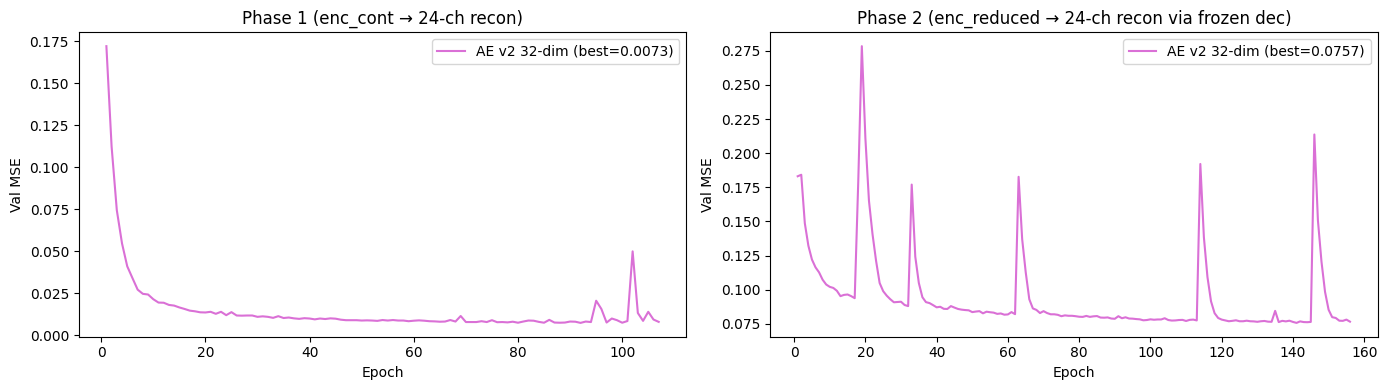

In [17]:
def parse_ae_curve(run_name, phase=2):
    """Parse (epoch, val_mse) for a given phase from ae training log."""
    logs = sorted(glob.glob(str(ROOT / f'outputs/{run_name}/ae_*.log')))
    if not logs:
        raise FileNotFoundError(f'No ae log found under outputs/{run_name}/')
    epochs, val_mse = [], []
    in_target = False
    phase_start = f'Phase {phase}: loading'
    next_phase  = f'Phase {phase + 1}:' if phase < 2 else 'Phase 2 done'
    for line in open(logs[-1]):
        if phase_start in line:
            in_target = True
        if in_target and next_phase in line and phase_start not in line:
            in_target = False
        if in_target:
            m = re.search(r'epoch\s+(\d+)/\d+\s+val_mse=([\d.]+)', line)
            if m:
                epochs.append(int(m.group(1)))
                val_mse.append(float(m.group(2)))
    return epochs, val_mse

ep1_new, v1_new = parse_ae_curve(AE_RUN, phase=1)
ep2_new, v2_new = parse_ae_curve(AE_RUN, phase=2)

info_new  = json.load(open(ROOT / f'outputs/{AE_RUN}/ae_info.json'))

print(f"AE v2 (32-dim):")
print(f"  Phase 1: {info_new['training']['phase1_epochs_run']} epochs, best val MSE {info_new['training']['phase1_best_val']:.4f}")
print(f"  Phase 2: {info_new['training']['phase2_epochs_run']} epochs, best val MSE {info_new['training']['phase2_best_val']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (ep, val, title) in zip(axes, [
    (ep1_new, v1_new, 'Phase 1 (enc_cont → 24-ch recon)'),
    (ep2_new, v2_new, 'Phase 2 (enc_reduced → 24-ch recon via frozen dec)'),
]):
    ax.plot(ep, val, color='orchid', linewidth=1.5, label=f'AE v2 32-dim (best={min(val):.4f})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val MSE')
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.show()

## Embedding diagnostics

In [18]:
emb_net = posterior.posterior_estimator.embedding_net

with torch.no_grad():
    emb_out = emb_net(x_test[:64].to(device))
print(f'Embedding output shape: {emb_out.shape}')  # expect (64, 32)
print(f'Per-dim std  min/mean/max: '
      f'{emb_out.std(0).min():.4f} / {emb_out.std(0).mean():.4f} / {emb_out.std(0).max():.4f}')
print(f'Overall mean: {emb_out.mean():.4f}  std: {emb_out.std():.4f}')

Embedding output shape: torch.Size([64, 32])
Per-dim std  min/mean/max: 0.0867 / 0.1642 / 0.2824
Overall mean: 0.0003  std: 0.1789


## Spectral norm per layer

Layer                                  σ₁
--------------------------------------------
  cnn.0                            1.9980  ← AT CEILING
  cnn.2                            1.9994  ← AT CEILING
  cnn.4                            2.0040  ← AT CEILING
  cnn.6                            1.9954  ← AT CEILING
  scalar_projs.0                   2.0000  ← AT CEILING
  scalar_projs.1                   2.0000  ← AT CEILING
  scalar_projs.2                   2.0000  ← AT CEILING
  scalar_projs.3                   2.0000  ← AT CEILING
  scalar_projs.4                   2.0000  ← AT CEILING
  attn_pool                        1.2922
  proj                             1.9980  ← AT CEILING

max σ₁: 2.0040


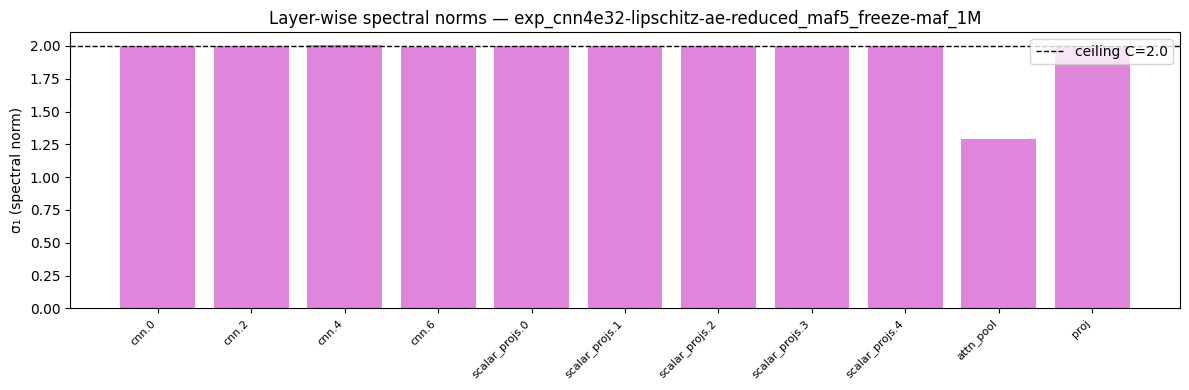

In [19]:
def compute_spectral_norms(encoder, device='cpu'):
    norms = {}
    for name, mod in encoder.named_modules():
        if not isinstance(mod, (torch.nn.Conv1d, torch.nn.Linear)): continue
        if not hasattr(mod, 'weight') or mod.weight is None: continue
        W = mod.weight.detach().to(device).reshape(mod.weight.shape[0], -1)
        u = F.normalize(torch.randn(W.shape[0], device=device), dim=0)
        for _ in range(20):
            v = F.normalize(W.t() @ u, dim=0)
            u = F.normalize(W @ v,   dim=0)
        norms[name] = (u @ (W @ v)).item()
    return norms

sn = compute_spectral_norms(emb_net, device=device)
layers = list(sn.keys())

print(f"{'Layer':<30} {'σ₁':>10}")
print('-' * 44)
for k, v in sn.items():
    flag = '  ← AT CEILING' if v >= 1.99 else ''
    print(f"  {k:<28} {v:>10.4f}{flag}")
print(f"\nmax σ₁: {max(sn.values()):.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(layers)), list(sn.values()), color='orchid', alpha=0.85)
ax.axhline(2.0, color='black', linestyle='--', linewidth=1, label='ceiling C=2.0')
ax.set_xticks(range(len(layers)))
ax.set_xticklabels(layers, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('σ₁ (spectral norm)')
ax.set_title(f'Layer-wise spectral norms — {RUN_NAME}')
ax.legend()
plt.tight_layout()
plt.show()

## Lipschitz ratio test — ||f(x) - f(y)|| / ||x - y||

Lipschitz ratio over 500 pairs:
  mean=0.039  median=0.036  95th=0.066  max=0.129


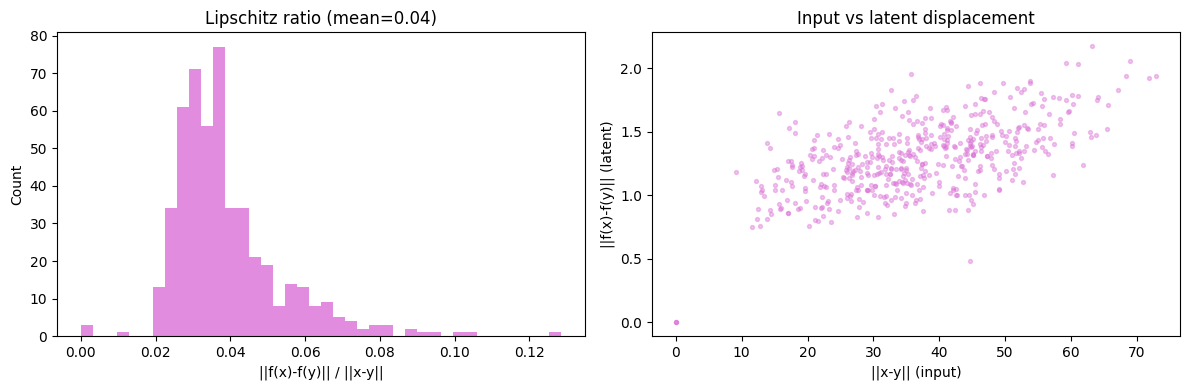

In [20]:
N_PAIRS = 500
idx_a = torch.randint(len(x_test), (N_PAIRS,))
idx_b = torch.randint(len(x_test), (N_PAIRS,))
x_a   = x_test[idx_a].to(device)
x_b   = x_test[idx_b].to(device)

with torch.no_grad():
    z_a = emb_net(x_a)
    z_b = emb_net(x_b)

dx    = (x_a - x_b).norm(dim=1).cpu().numpy()
dz    = (z_a - z_b).norm(dim=1).cpu().numpy()
ratio = dz / (dx + 1e-12)

print(f"Lipschitz ratio over {N_PAIRS} pairs:")
print(f"  mean={ratio.mean():.3f}  median={np.median(ratio):.3f}  "
      f"95th={np.percentile(ratio, 95):.3f}  max={ratio.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ratio, bins=40, color='orchid', alpha=0.8)
axes[0].set_xlabel('||f(x)-f(y)|| / ||x-y||'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Lipschitz ratio (mean={ratio.mean():.2f})')
axes[1].scatter(dx, dz, s=8, alpha=0.4, color='orchid')
axes[1].set_xlabel('||x-y|| (input)'); axes[1].set_ylabel('||f(x)-f(y)|| (latent)')
axes[1].set_title('Input vs latent displacement')
plt.tight_layout()
plt.show()

## Sample posterior for each test observation

In [21]:
all_means, all_q05, all_q95 = [], [], []

for i, x_o in enumerate(x_test):
    samples = posterior.sample((N_POSTERIOR_SAMPLES,), x=x_o.to(device), show_progress_bars=False)
    all_means.append(samples.mean(dim=0).cpu())
    all_q05.append(samples.quantile(0.05, dim=0).cpu())
    all_q95.append(samples.quantile(0.95, dim=0).cpu())
    if (i + 1) % 50 == 0:
        print(f'  {i + 1}/{len(x_test)} done')

pred_mean = torch.stack(all_means).numpy()  # (256, 24)
q05       = torch.stack(all_q05).numpy()
q95       = torch.stack(all_q95).numpy()
gt_phys   = theta_gt.numpy()

print(f'Posterior mean shape: {pred_mean.shape}')

  50/256 done
  100/256 done
  150/256 done


                    accepted. It may take a long time to collect the remaining
                    948 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


  200/256 done
  250/256 done
Posterior mean shape: (256, 24)


## Point-estimate metrics

In [22]:
abs_err = np.abs(pred_mean - gt_phys)
ch_mae  = abs_err.mean(axis=0)
ch_med  = np.median(abs_err, axis=0)
ch_mape = (abs_err / (np.abs(gt_phys) + 1e-9) * 100).mean(axis=0)

print(f"{'Parameter':<14} {'MAE':>12} {'Median AE':>12} {'MAPE (%)':>10}")
print('-' * 52)
for i, name in enumerate(PARAM_KEYS_INFER):
    print(f'{name:<14} {ch_mae[i]:>12.4f} {ch_med[i]:>12.4f} {ch_mape[i]:>10.2f}%')

print(f'\nOverall  MAE (mean): {ch_mae.mean():.4f}  MAPE: {ch_mape.mean():.2f}%')

Parameter               MAE    Median AE   MAPE (%)
----------------------------------------------------
AVD                 20.1591      11.9327      13.62%
Bla                  0.0203       0.0190      35.89%
Blv                  0.0088       0.0083      26.55%
Bra                  0.0100       0.0078      19.90%
Brv                  0.0027       0.0018       7.86%
Cas                  0.0105       0.0065       0.93%
Cvp                  0.6694       0.4930      17.65%
Cvs                 20.8267      19.9431      35.94%
Eap                  0.0165       0.0027       1.19%
Eedref_la            0.5041       0.4550      99.76%
Eedref_lv            0.3870       0.3538     104.91%
Eedref_ra            0.1785       0.1090      64.59%
Eedref_rv            0.0790       0.0416      20.29%
Emax_LA              0.1220       0.0930      31.66%
Emax_LV              0.7124       0.5830      37.22%
Emax_RA              0.0730       0.0524      21.19%
Emax_RV              0.0248       0.0131       

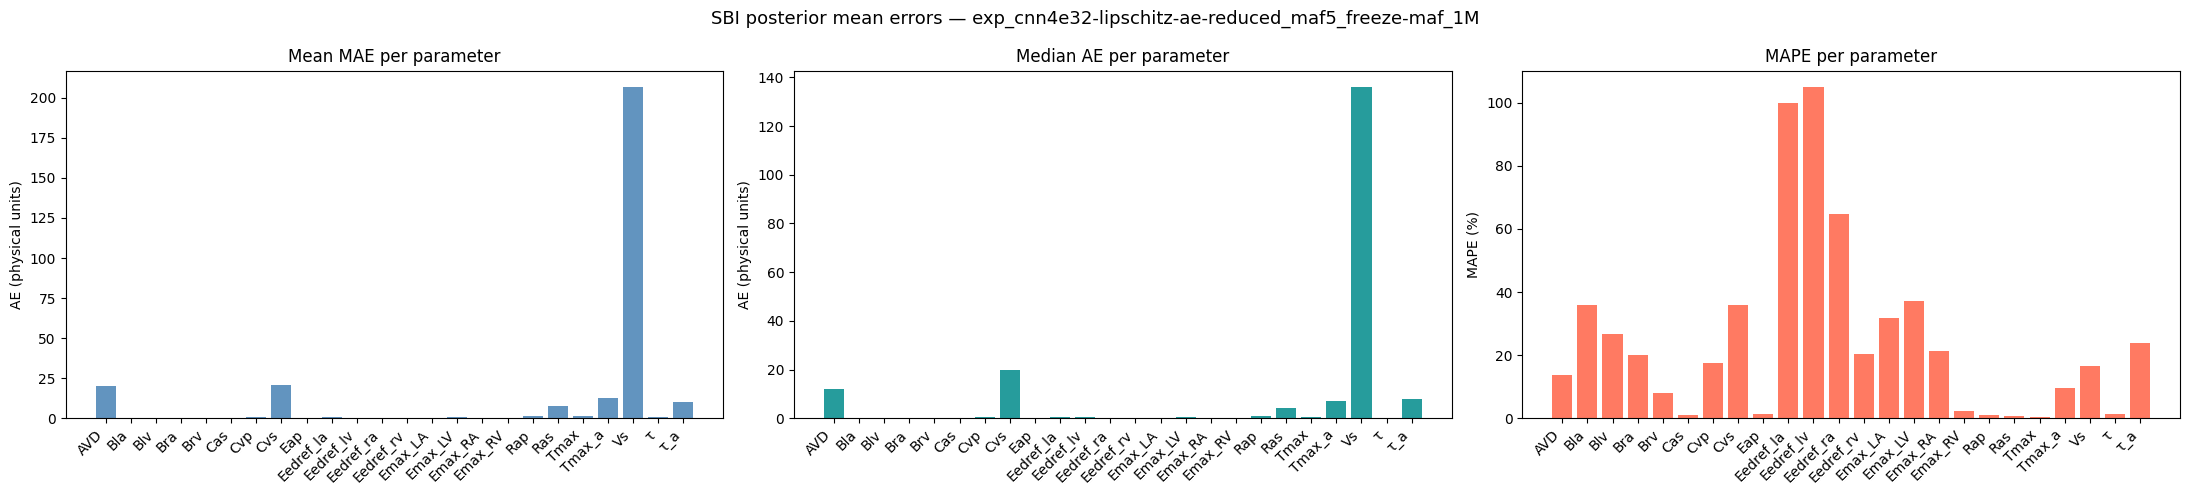

In [27]:
x_pos = np.arange(len(PARAM_KEYS_INFER))
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

axes[0].bar(x_pos, ch_mae,  color='steelblue', alpha=0.85)
axes[1].bar(x_pos, ch_med,  color='darkcyan',  alpha=0.85)
axes[2].bar(x_pos, ch_mape, color='tomato',    alpha=0.85)

for ax, title, ylabel in zip(axes,
    ['Mean MAE per parameter', 'Median AE per parameter', 'MAPE per parameter'],
    ['AE (physical units)', 'AE (physical units)', 'MAPE (%)']):
    ax.set_xticks(x_pos)
    ax.set_xticklabels(PARAM_KEYS_INFER, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel(ylabel)

fig.suptitle(f'SBI posterior mean errors — {RUN_NAME}', fontsize=13)
plt.tight_layout()
plt.show()

## Predicted vs GT scatter — 24 parameters

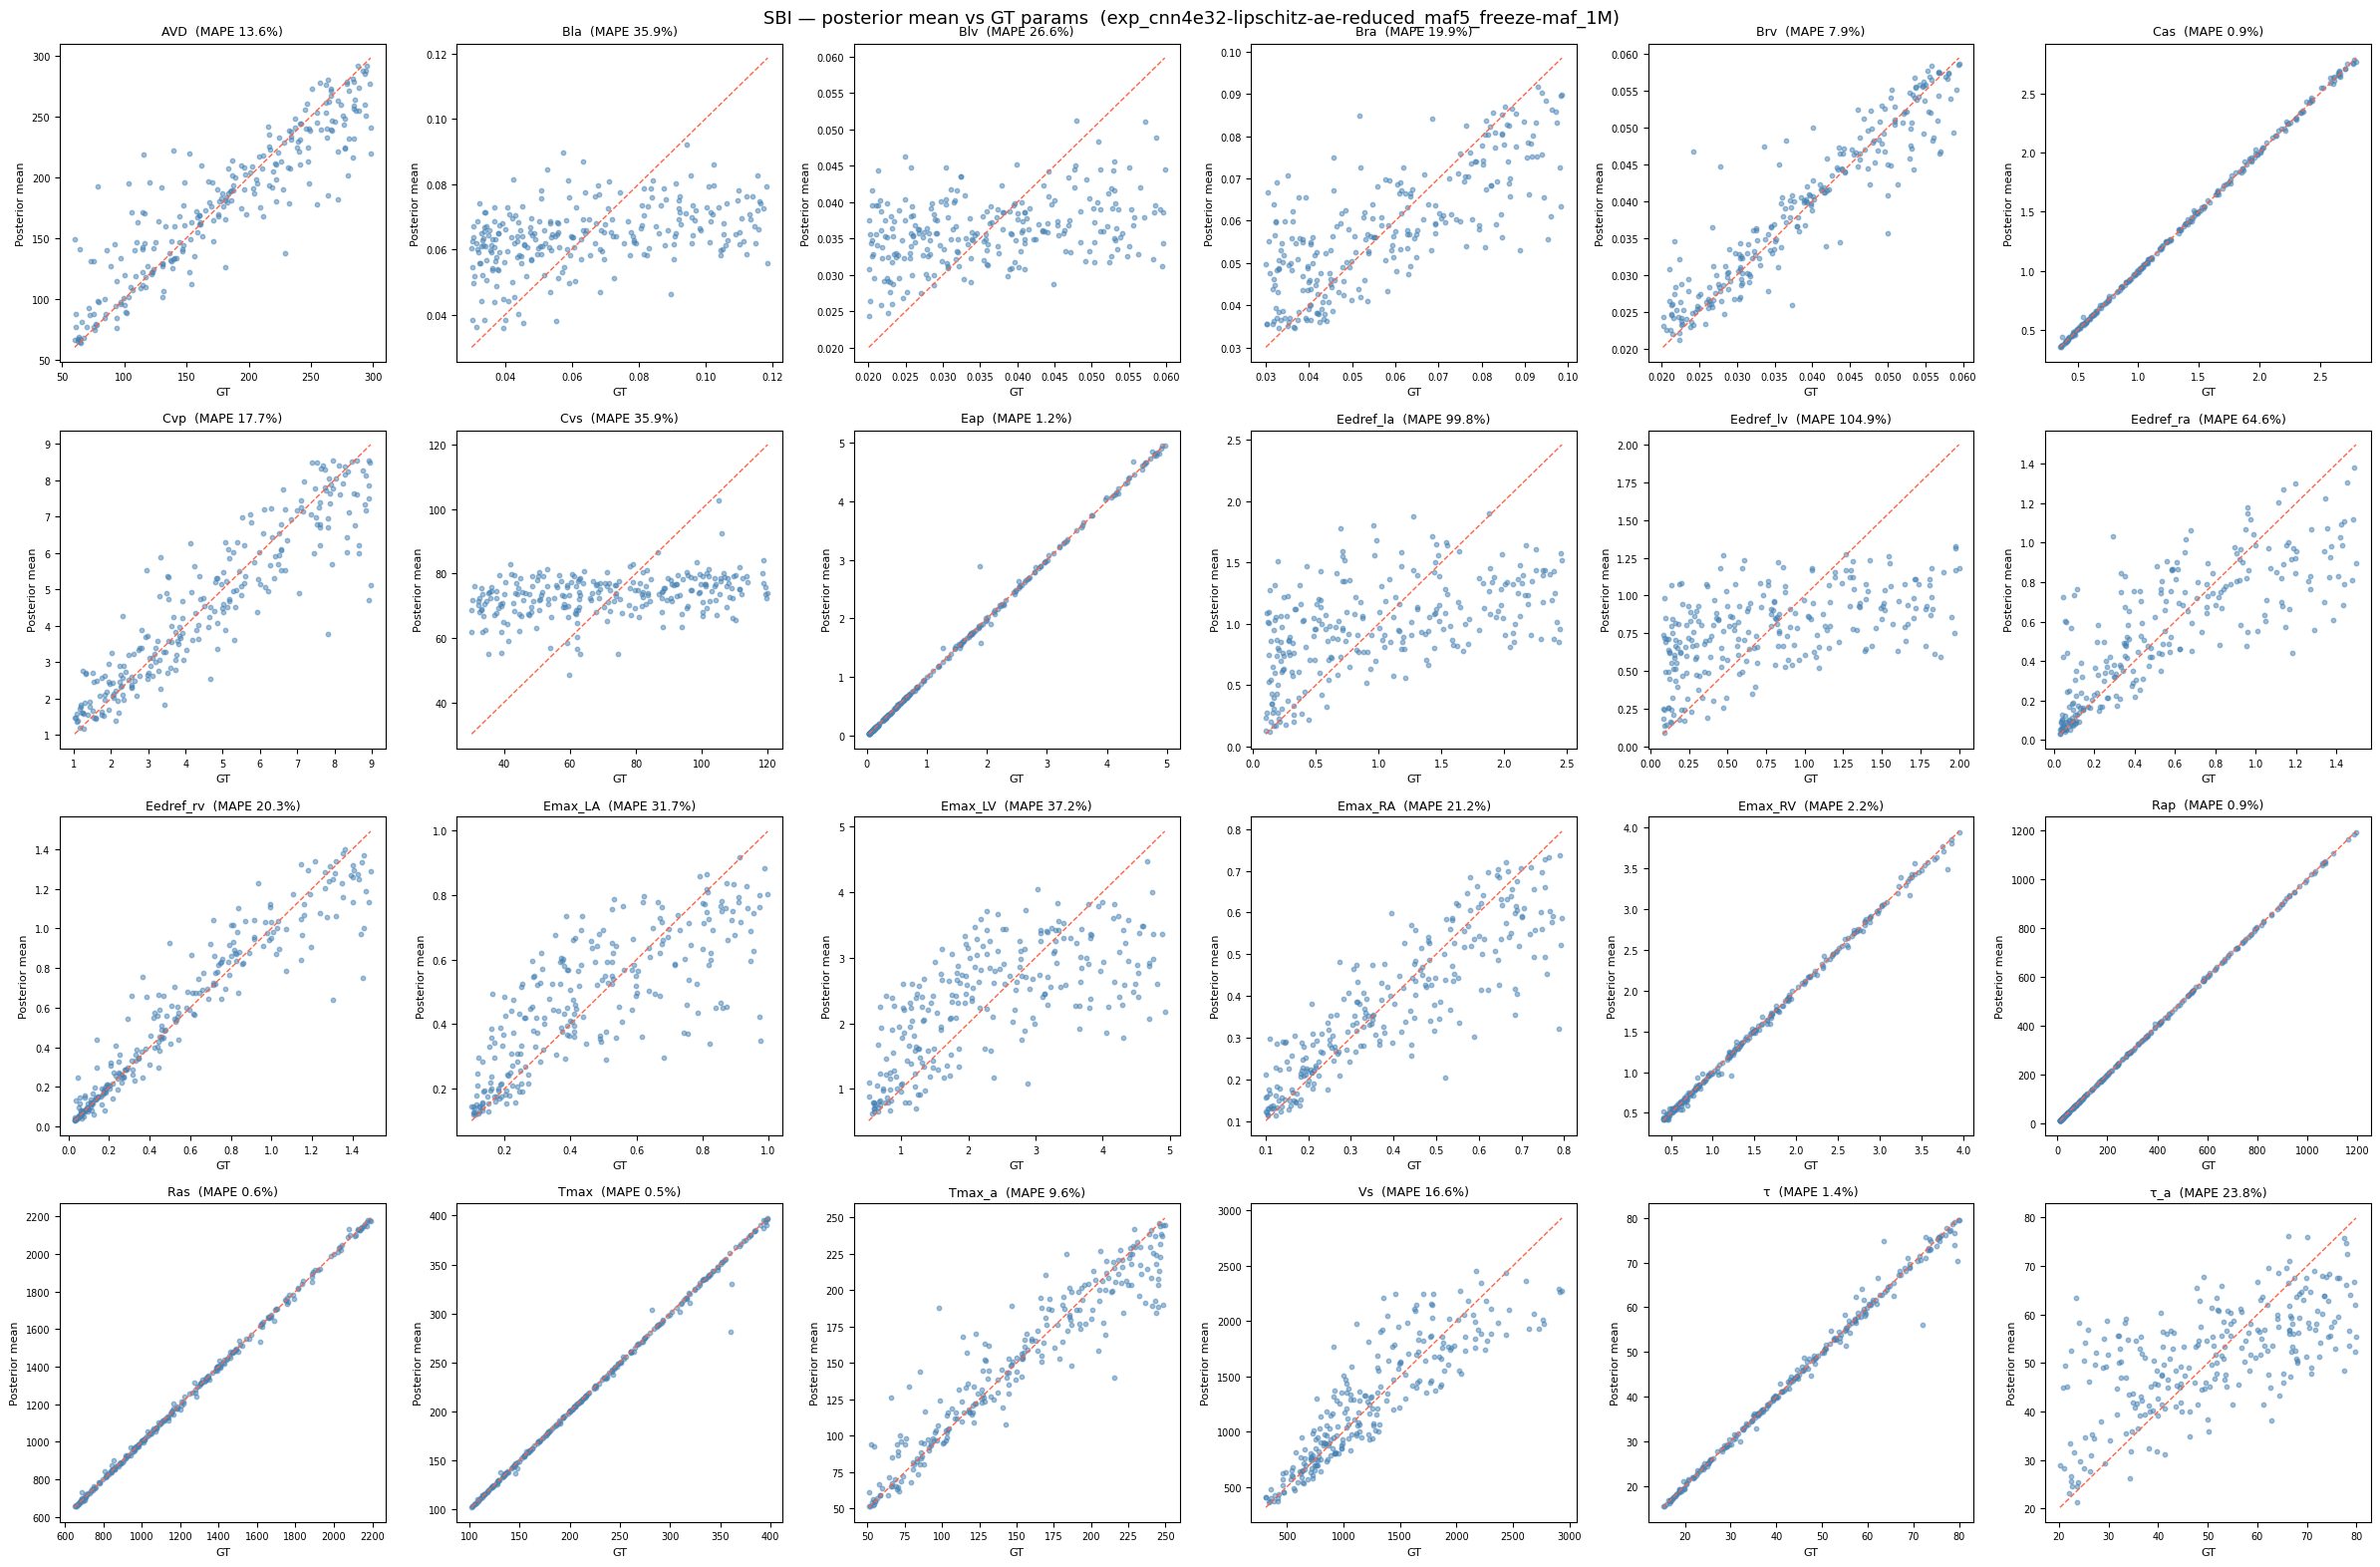

In [28]:
ncols, nrows = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))

for i, name in enumerate(PARAM_KEYS_INFER):
    ax = axes[i // ncols, i % ncols]
    gt_i, pred_i = gt_phys[:, i], pred_mean[:, i]
    lo, hi = gt_i.min(), gt_i.max()
    ax.scatter(gt_i, pred_i, s=10, alpha=0.5, color='steelblue')
    ax.plot([lo, hi], [lo, hi], color='tomato', linewidth=1, linestyle='--')
    ax.set_title(f'{name}  (MAPE {ch_mape[i]:.1f}%)', fontsize=9)
    ax.set_xlabel('GT', fontsize=8)
    ax.set_ylabel('Posterior mean', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle(f'SBI — posterior mean vs GT params  ({RUN_NAME})', fontsize=13)
plt.tight_layout()
plt.show()

## 90% credible interval coverage

Parameter         90% CI coverage
-----------------------------------
AVD                        82.4%  ←
Bla                        80.9%  ←
Blv                        80.9%  ←
Bra                        80.9%  ←
Brv                        88.3%  ✓
Cas                        88.3%  ✓
Cvp                        80.9%  ←
Cvs                        80.9%  ←
Eap                        98.0%  ←
Eedref_la                  85.5%  ✓
Eedref_lv                  84.8%  ←
Eedref_ra                  81.2%  ←
Eedref_rv                  84.8%  ←
Emax_LA                    89.1%  ✓
Emax_LV                    82.8%  ←
Emax_RA                    81.6%  ←
Emax_RV                    91.0%  ✓
Rap                        96.1%  ←
Ras                        89.5%  ✓
Tmax                       96.1%  ←
Tmax_a                     84.0%  ←
Vs                         80.9%  ←
τ                          93.0%  ✓
τ_a                        82.8%  ←

Mean coverage: 86.0%  (target: 90%)


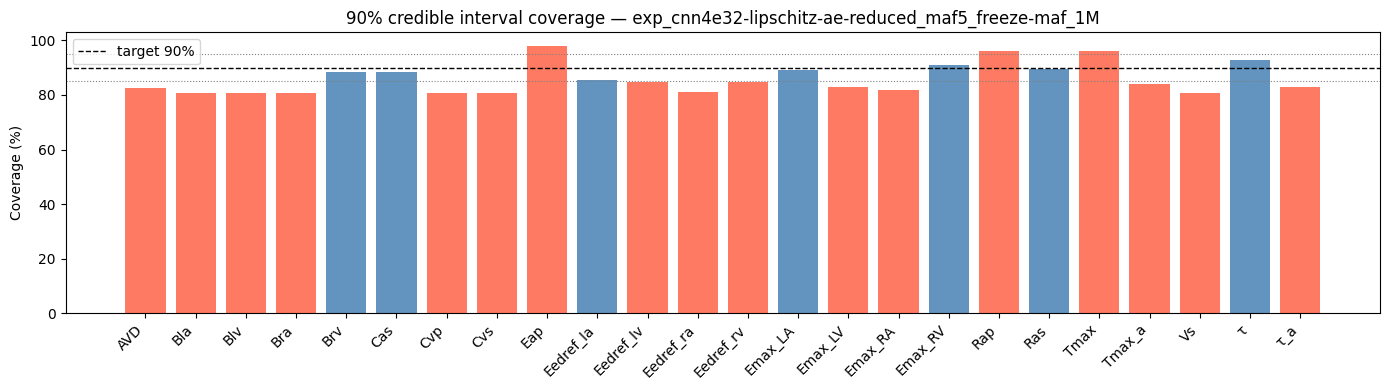

In [29]:
in_ci    = (gt_phys >= q05) & (gt_phys <= q95)
coverage = in_ci.mean(axis=0) * 100

print(f"{'Parameter':<14} {'90% CI coverage':>18}")
print('-' * 35)
for i, name in enumerate(PARAM_KEYS_INFER):
    flag = '  ✓' if 85 <= coverage[i] <= 95 else '  ←'
    print(f'{name:<14} {coverage[i]:>16.1f}%{flag}')

print(f'\nMean coverage: {coverage.mean():.1f}%  (target: 90%)')

x_pos  = np.arange(len(PARAM_KEYS_INFER))
fig, ax = plt.subplots(figsize=(14, 4))
colors  = ['steelblue' if 85 <= c <= 95 else 'tomato' for c in coverage]
ax.bar(x_pos, coverage, color=colors, alpha=0.85)
ax.axhline(90, color='black', linestyle='--', linewidth=1, label='target 90%')
ax.axhline(85, color='gray',  linestyle=':',  linewidth=0.8)
ax.axhline(95, color='gray',  linestyle=':',  linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(PARAM_KEYS_INFER, rotation=45, ha='right')
ax.set_ylabel('Coverage (%)')
ax.set_title(f'90% credible interval coverage — {RUN_NAME}')
ax.legend()
plt.tight_layout()
plt.show()

## Direct inference on real patients — Cas, Eap, Rap, Ras

In [31]:
import os

REAL_DATA_PATH = Path(os.path.expanduser('~/real_data/multibeat'))
REAL_PARAMS    = ['Cas', 'Eap', 'Rap', 'Ras']
PARAM_IDX      = {name: i for i, name in enumerate(PARAM_KEYS_INFER)}

real_files = sorted(REAL_DATA_PATH.glob('*.pt'))
print(f'Found {len(real_files)} real patient files')

results = []
for fpath in real_files[:10]:  # first 10 patients
    x_real = torch.load(fpath, map_location='cpu', weights_only=False)
    if x_real.dim() == 2:
        x_real = x_real.mean(0)  # average beats
    with torch.no_grad():
        samples = posterior.sample((500,), x=x_real.to(device), show_progress_bars=False)
    post_mean = samples.mean(0).cpu()
    post_std  = samples.std(0).cpu()
    results.append({'file': fpath.stem, 'mean': post_mean, 'std': post_std})

print(f"\n{'Patient':<20}  " + '  '.join(f'{p:>10}' for p in REAL_PARAMS))
print('-' * (20 + 14 * len(REAL_PARAMS)))
for r in results:
    vals = '  '.join(f"{r['mean'][PARAM_IDX[p]].item():>8.4f}±{r['std'][PARAM_IDX[p]].item():.3f}"
                     for p in REAL_PARAMS)
    print(f"{r['file']:<20}  {vals}")

Found 0 real patient files

Patient                      Cas         Eap         Rap         Ras
----------------------------------------------------------------------------
